In [1]:
# Repository path setup. This lets the notebook run from either the repo root or the notebooks/ folder.
from pathlib import Path
import os

_REPO_ROOT = Path.cwd()
if not (_REPO_ROOT / "data").exists() and (_REPO_ROOT.parent / "data").exists():
    _REPO_ROOT = _REPO_ROOT.parent
os.chdir(_REPO_ROOT)
# print(f"Working directory: {_REPO_ROOT}")

# Minimal notebook to generate `Figure4_AUROC.pdf`

Raw data: 2199
Filter all missing: 2030
Filter all positive: 2027
Filter all negative: 1929
[1. 2. 3. 4. 5.]
[epoch 1] val AUROC=0.837 val F1=0.780
[epoch 2] val AUROC=0.860 val F1=0.819
[epoch 3] val AUROC=0.867 val F1=0.807
[epoch 4] val AUROC=0.876 val F1=0.811
[epoch 5] val AUROC=0.878 val F1=0.823
[epoch 6] val AUROC=0.879 val F1=0.805
[epoch 7] val AUROC=0.879 val F1=0.826
[epoch 8] val AUROC=0.878 val F1=0.821
[epoch 9] val AUROC=0.880 val F1=0.813
[epoch 10] val AUROC=0.880 val F1=0.822
[epoch 11] val AUROC=0.881 val F1=0.824
[epoch 12] val AUROC=0.877 val F1=0.814
[epoch 13] val AUROC=0.880 val F1=0.805
[epoch 14] val AUROC=0.881 val F1=0.814
[epoch 15] val AUROC=0.877 val F1=0.823
[epoch 16] val AUROC=0.880 val F1=0.812
[epoch 17] val AUROC=0.880 val F1=0.807
[epoch 18] val AUROC=0.882 val F1=0.824
[epoch 19] val AUROC=0.883 val F1=0.822
[epoch 20] val AUROC=0.875 val F1=0.799
[epoch 21] val AUROC=0.877 val F1=0.819
[epoch 22] val AUROC=0.880 val F1=0.821
[epoch 23] val AUROC

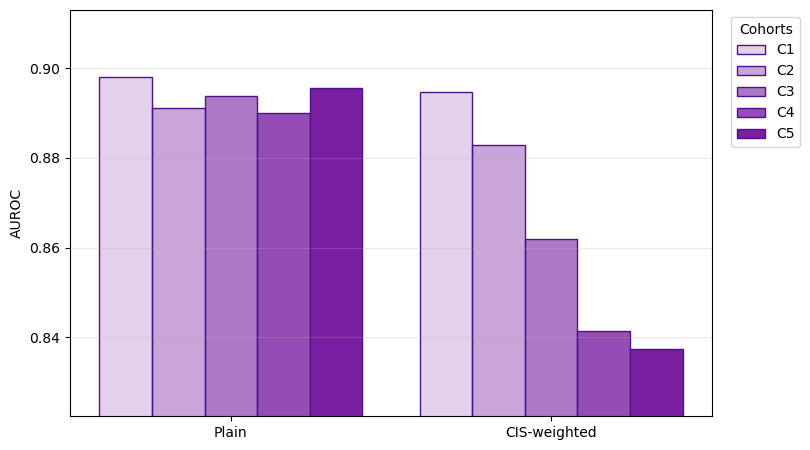

In [7]:
import warnings
warnings.filterwarnings("ignore")
def generate_dataset_from_dataframe(
    df, miss_value, random_seed=42, future_window=4, n_timesteps=24,
    daily_treatment=True, restrict_length=-1, select_class=None, prev_week_mode=1,
    include_treat_stats=True,
    include_tlstm_treat=True
):
    import numpy as np
    import torch
    import torch.nn as nn
    from torch.utils.data import TensorDataset

    np.random.seed(random_seed)

    static_features = df[['treatment_group','age', 'race', 'is_male', 'heroin_inject', 'TLFB_Heroin',
                          'TLFB_THC', 'TLFB_Alcohol', 'TLFB_Cocaine', 'TLFB_Methadone',
                          'TLFB_Amphetamine', 'UDS_Benzodiazepine', 'UDS_Opioid',
                          'UDS_Thc', 'UDS_Buprenorphine', 'UDS_Methadone', 'UDS_Cocaine',
                          'UDS_Alcohol', 'UDS_Amphetamine', 'UDS_Sedatives', 'UDS_Mdma/Hallucinogen']].values

    treat_features = df['treat_wks'].tolist()

    # ----- ORIGINAL weekly time-series features -----
    time_series_raw = df.filter(regex='week').values
    time_series_raw[time_series_raw == -1] = miss_value

    N = time_series_raw.shape[0]
    n_orig_features = time_series_raw.shape[1] // n_timesteps
    orig_weekly = (
        time_series_raw
        .reshape(N, n_orig_features, n_timesteps)
        .transpose(0, 2, 1)
    )  # (N, 24, n_orig_features)

    if include_treat_stats:
        week_len = 7

        def parse_daily_seq(colname):
            seq_list = df[colname].tolist()
            daily_arr = []
            for s in seq_list:
                if not isinstance(s, str) or s.strip() == "":
                    arr = np.zeros(n_timesteps * week_len, dtype=float)
                else:
                    vals = s.split(',')
                    if len(vals) < n_timesteps * week_len:
                        vals = vals + ['0'] * (n_timesteps * week_len - len(vals))
                    elif len(vals) > n_timesteps * week_len:
                        vals = vals[:n_timesteps * week_len]
                    arr = np.array([float(x) for x in vals], dtype=float)
                daily_arr.append(arr)
            daily_arr = np.stack(daily_arr, axis=0)  # (N, 168)
            return daily_arr.reshape(N, n_timesteps, week_len)  # (N, 24, 7)

        def weekly_stats(daily_3d):
            wk_min  = daily_3d.min(axis=2, keepdims=True)
            wk_max  = daily_3d.max(axis=2, keepdims=True)
            wk_mean = daily_3d.mean(axis=2, keepdims=True)
            return np.concatenate([wk_min, wk_max, wk_mean], axis=2)  # (N, 24, 3)

        bup_stats = weekly_stats(parse_daily_seq('treat_Buprenorphine_amt'))
        met_stats = weekly_stats(parse_daily_seq('treat_Methadone_amt'))
        ntx_stats = weekly_stats(parse_daily_seq('treat_Naltrexone_amt'))

        treat_weekly_stats = np.concatenate([bup_stats, met_stats, ntx_stats], axis=2)  # (N, 24, 9)
        time_series_features = np.concatenate([orig_weekly, treat_weekly_stats], axis=2)
    else:
        time_series_features = orig_weekly

    def create_variable_length_sequences_with_labels(static_features, time_series_features, treat_features):
        X_static_list, X_time_series_list, y_list = [], [], []
        sample_index, week_index, T_time_series_list = [], [], []
        week_len = 7
        start_week = 3

        for i in range(len(static_features)):
            treat_rec = np.array([float(ele) for ele in treat_features[i].split(',')])

            for t in range(start_week, n_timesteps - future_window):
                if (select_class is not None) and (time_series_features[i, t, 0] != select_class):
                    continue
                if restrict_length != -1 and (t + 1 != restrict_length):
                    continue

                if include_tlstm_treat:
                    treat_ts = treat_rec.reshape(n_timesteps, week_len)
                    if prev_week_mode == 1:
                        T_time_series_list.append(treat_ts[:t+1, :])
                    elif prev_week_mode == 2:
                        T_time_series_list.append(treat_ts[t-3:t+1, :])
                    elif prev_week_mode == 3:
                        temp_vec = treat_ts[:t+1, :].copy()
                        temp_vec[:-3] = -3
                        T_time_series_list.append(temp_vec)

                X_static_list.append(static_features[i])

                if prev_week_mode == 1:
                    X_time_series_list.append(time_series_features[i, :t+1, :])
                    week_index.append(t)
                elif prev_week_mode == 2:
                    X_time_series_list.append(time_series_features[i, t-3:t+1, :])
                    week_index.append(3)
                elif prev_week_mode == 3:
                    temp_vec = time_series_features[i, :t+1, :].copy()
                    temp_vec[:-3] = -3
                    X_time_series_list.append(temp_vec)
                    week_index.append(t)

                sample_index.append(i)

                labels = time_series_features[i, t+1, 0]
                labels = 1 if labels != 0 else 0
                y_list.append(labels)

        return X_static_list, X_time_series_list, y_list, sample_index, week_index, T_time_series_list

    X_static, X_time_series, y, sample_index, week_index, T_time_series = create_variable_length_sequences_with_labels(
        static_features, time_series_features, treat_features
    )

    # tensors + padding
    X_static = torch.tensor(X_static, dtype=torch.float32)
    y = torch.tensor(y, dtype=torch.long)  # better: long for CrossEntropy
    X_time_series = [torch.tensor(seq, dtype=torch.float32) for seq in X_time_series]
    X_time_series = nn.utils.rnn.pad_sequence(X_time_series, batch_first=True)
    sample_index = torch.tensor(sample_index, dtype=torch.int64)
    week_index = torch.tensor(week_index, dtype=torch.int64)

    if include_tlstm_treat:
        T_time_series = [torch.tensor(seq, dtype=torch.float32) for seq in T_time_series]
        T_time_series = nn.utils.rnn.pad_sequence(T_time_series, batch_first=True)
        dataset = TensorDataset(X_time_series, X_static, y, sample_index, week_index, T_time_series)
    else:
        dataset = TensorDataset(X_time_series, X_static, y, sample_index, week_index)

    return dataset

########### Define LSTM model, assuming Static Features Impact Predictions Over Time (time-dependent)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

class TimeDependentLSTM(nn.Module):
    def __init__(self, input_size1, hidden_size, num_static_features, input_size2=7):
        super(TimeDependentLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size1, hidden_size, batch_first=True)
        self.fc_time_series = nn.Linear(hidden_size, 32)
        self.tlstm = nn.LSTM(input_size2, hidden_size, batch_first=True)
        self.fc_t_time_series = nn.Linear(hidden_size, 32)
        self.fc_static = nn.Linear(num_static_features, 32)
        self.fc_combined_all = nn.Linear(96, 16)
        self.fc_combined = nn.Linear(64, 16)
        self.fc_single = nn.Linear(32, 16)
        self.output = nn.Linear(16, 2)

    def forward(self, x_time_series, x_static, t_time_series):
        lstm_out, _ = self.lstm(x_time_series)
        x_time_series = torch.relu(self.fc_time_series(lstm_out))

        if (not x_static is None) and (not t_time_series is None):
            # Expand static features across the time axis
            x_static_expanded = x_static.unsqueeze(1).expand(-1, x_time_series.size(1), -1)
            x_static = torch.relu(self.fc_static(x_static_expanded))

            tlstm_out, _ = self.tlstm(t_time_series)
            t_time_series = torch.relu(self.fc_t_time_series(tlstm_out))

            # Combine time-series and static features
            combined = torch.cat((x_time_series, t_time_series, x_static), dim=2)
            combined = torch.relu(self.fc_combined_all(combined))

            output = self.output(combined).squeeze(-1)
        elif not x_static is None:
            # Expand static features across the time axis
            x_static_expanded = x_static.unsqueeze(1).expand(-1, x_time_series.size(1), -1)
            x_static = torch.relu(self.fc_static(x_static_expanded))
            # Combine time-series and static features
            combined = torch.cat((x_time_series, x_static), dim=2)
            combined = torch.relu(self.fc_combined(combined))
            output = self.output(combined).squeeze(-1)
        elif not t_time_series is None:
            tlstm_out, _ = self.tlstm(t_time_series)
            t_time_series = torch.relu(self.fc_t_time_series(tlstm_out))
            combined = torch.cat((x_time_series, t_time_series), dim=2)
            combined = torch.relu(self.fc_combined(combined))
            output = self.output(combined).squeeze(-1)
        else:
            single = torch.relu(self.fc_single(x_time_series))
            output = self.output(single).squeeze(-1)

        return output

from sklearn.utils.class_weight import compute_class_weight
def load_LSTM_model_pars(train_dataset, hidden_size=64, lr=0.0005, device="cpu"):
    model = TimeDependentLSTM(
        train_dataset[0][0].shape[1],
        hidden_size,
        train_dataset[0][1].shape[0]
    ).to(device)

    classes = np.unique(train_dataset[:][2].numpy())
    class_weights = compute_class_weight(
        'balanced',
        classes=classes,
        y=train_dataset[:][2].numpy()
    )
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32, device=device)

    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    return model, criterion, optimizer


########### Initialize all models in our architecture

import os
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
import matplotlib.pyplot as plt

def fit_model(model, train_loader, val_loader, criterion, optimizer, no_static=False, include_tlstm_treat=False, n_epochs=15, device="cpu", return_history=False):
    model.to(device)
    best_val = -1
    best_state = None
    best_epoch = -1

    history = {"epoch": [], "train_loss": [], "val_loss": []}
    for epoch in range(n_epochs):
        model.train()
        train_loss_sum = 0.0
        train_n = 0
        val_loss_sum = 0.0
        val_n = 0
        for batch in train_loader:
            if include_tlstm_treat:
                x_ts, x_static, y, sample_idx, week_index, t_ts = batch
                t_ts = t_ts.to(device)
            else:
                x_ts, x_static, y, sample_idx, week_index = batch
                t_ts = None

            x_ts = x_ts.to(device)
            x_static = x_static.to(device)
            y = y.to(device)
            week_index = week_index.to(device)

            optimizer.zero_grad()
            logits_all = model(x_ts, None if no_static else x_static, t_ts)
            logits = logits_all[torch.arange(logits_all.size(0), device=device), week_index, :]
            loss = criterion(logits, y)
            train_loss_sum += loss.item() * y.size(0)
            train_n += y.size(0)
            loss.backward()
            optimizer.step()

        # quick val AUROC
        model.eval()
        with torch.no_grad():
            for batch in val_loader:
                if include_tlstm_treat:
                    x_ts, x_static, y, sample_idx, week_index, t_ts = batch
                    t_ts = t_ts.to(device)
                else:
                    x_ts, x_static, y, sample_idx, week_index = batch
                    t_ts = None

                x_ts = x_ts.to(device)
                x_static = x_static.to(device)
                y = y.to(device)
                week_index = week_index.to(device)

                logits_all = model(x_ts, None if no_static else x_static, t_ts)
                logits = logits_all[torch.arange(logits_all.size(0), device=device), week_index, :]
                val_loss = criterion(logits, y)

                val_loss_sum += val_loss.item() * y.size(0)
                val_n += y.size(0)

        val_metrics = evaluate_week_level(model, val_loader, no_static=no_static, include_tlstm_treat=include_tlstm_treat, device=device)
        if val_metrics["auroc"] > best_val:
            best_val = val_metrics["auroc"]
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            best_epoch = epoch

        print(f"[epoch {epoch+1}] val AUROC={val_metrics['auroc']:.3f} val F1={val_metrics['f1']:.3f}")
        history["epoch"].append(epoch + 1)
        history["train_loss"].append(train_loss_sum / max(train_n, 1))
        history["val_loss"].append(val_loss_sum / max(val_n, 1))

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history, best_epoch


def evaluate_week_level(model, loader, no_static=False, include_tlstm_treat=False, device="cpu"):
    model.eval()
    ys = []
    ps = []

    with torch.no_grad():
        for batch in loader:
            if include_tlstm_treat:
                x_ts, x_static, y, sample_idx, week_index, t_ts = batch
                t_ts = t_ts.to(device)
            else:
                x_ts, x_static, y, sample_idx, week_index = batch
                t_ts = None

            x_ts = x_ts.to(device)
            x_static = x_static.to(device)
            y = y.to(device)
            week_index = week_index.to(device)

            logits_all = model(x_ts, None if no_static else x_static, t_ts)
            logits = logits_all[torch.arange(logits_all.size(0), device=device), week_index, :]
            prob = F.softmax(logits, dim=1)[:, 1]  # P(relapse)

            ys.append(y.detach().cpu().numpy())
            ps.append(prob.detach().cpu().numpy())

    y_all = np.concatenate(ys)
    p_all = np.concatenate(ps)

    auroc = roc_auc_score(y_all, p_all)
    auprc = average_precision_score(y_all, p_all)

    pred = (p_all >= 0.5).astype(int)
    f1 = f1_score(y_all, pred)

    return {"auroc": auroc, "auprc": auprc, "f1": f1}


def evaluate_by_pe_tier(model, df_test, test_dataset, no_static=False, include_tlstm_treat=False, device="cpu"):
    """
    df_test rows correspond to patients; test_dataset contains many (patient, week) samples.
    We'll use sample_index to map week-level samples back to patient PE tier.
    """
    loader = DataLoader(test_dataset, batch_size=512, shuffle=False)
    model.eval()

    tiers = df_test["Target_Permutation_Entropy"].values
    tier_y = {}
    tier_p = {}

    with torch.no_grad():
        for batch in loader:
            if include_tlstm_treat:
                x_ts, x_static, y, sample_idx, week_index, t_ts = batch
                t_ts = t_ts.to(device)
            else:
                x_ts, x_static, y, sample_idx, week_index = batch
                t_ts = None

            x_ts = x_ts.to(device)
            x_static = x_static.to(device)
            week_index = week_index.to(device)

            logits_all = model(x_ts, None if no_static else x_static, t_ts)
            logits = logits_all[torch.arange(logits_all.size(0), device=device), week_index, :]
            p = F.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()
            y_np = y.detach().cpu().numpy()
            sidx = sample_idx.detach().cpu().numpy()

            for yi, pi, si in zip(y_np, p, sidx):
                tier = int(tiers[int(si)])
                tier_y.setdefault(tier, []).append(int(yi))
                tier_p.setdefault(tier, []).append(float(pi))

    out = {}
    for tier in sorted(tier_y.keys()):
        yv = np.array(tier_y[tier])
        pv = np.array(tier_p[tier])
        if len(np.unique(yv)) < 2:
            out[tier] = {"n": len(yv), "auroc": np.nan, "auprc": np.nan}
        else:
            out[tier] = {
                "n": len(yv),
                "auroc": roc_auc_score(yv, pv),
                "auprc": average_precision_score(yv, pv),
            }
    return out


def plot_pe_tier_metrics(metrics_a, metrics_b, label_a, label_b, outpath):
    tiers = sorted(set(metrics_a.keys()) | set(metrics_b.keys()))
    auroc_a = [metrics_a.get(t, {}).get("auroc", np.nan) for t in tiers]
    auroc_b = [metrics_b.get(t, {}).get("auroc", np.nan) for t in tiers]

    x = np.arange(len(tiers))
    plt.figure(figsize=(8, 4))
    plt.plot(x, auroc_a, marker="o", label=label_a)
    plt.plot(x, auroc_b, marker="o", label=label_b)
    plt.xticks(x, tiers)
    plt.xlabel("Permutation Entropy Tier")
    plt.ylabel("AUROC (week-level)")
    plt.ylim(0.5, 1.0)
    plt.legend()
    plt.tight_layout()
    plt.savefig(outpath, dpi=200)
    plt.close()

import math
import numpy as np
from collections import Counter

def calculate_permutation_entropy(time_series, D=3):
    """
    Calculate normalized permutation entropy for a categorical time series.
    """
    n = len(time_series)
    if n < D:
        raise ValueError("Time-series length must be greater than embedding dimension.")

    ordinal_patterns = []
    for i in range(n - D + 1):
        segment = time_series[i:i + D]
        ordinal_pattern = tuple(np.argsort(segment))
        ordinal_patterns.append(ordinal_pattern)

    pattern_counts = Counter(ordinal_patterns)
    total_patterns = len(ordinal_patterns)
    probabilities = np.array(list(pattern_counts.values())) / total_patterns

    permutation_entropy = -np.sum(probabilities * np.log(probabilities))
    max_entropy = np.log(math.factorial(D))
    return permutation_entropy / max_entropy

def hamming_distance(ts1, ts2):
    assert len(ts1) == len(ts2), "Time-series must have the same length"
    return np.sum(ts1 != ts2) / len(ts1)

# Prefix-PE + CIS-weighted metrics utilities
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score

def get_prediction_weeks(n_timesteps=24, future_window=1, start_week=3):
    return np.arange(start_week, n_timesteps - future_window, dtype=int)

def compute_prefix_complexity_matrix_from_weekly(df, opioid_prefix="Opioid_week", n_timesteps=24, D=3):
    """
    Compute normalized permutation entropy for every prefix x_{0:t} of the weekly opioid sequence.
    Returns an array of shape (N, n_timesteps), with NaN for prefixes shorter than D.
    """
    cols = [f"{opioid_prefix}{i}" for i in range(n_timesteps)]
    if cols[0] not in df.columns:
        cols = [c for c in df.columns if c.startswith(opioid_prefix)][:n_timesteps]
    x = df[cols].to_numpy(dtype=float)
    pe = np.full((df.shape[0], n_timesteps), np.nan, dtype=float)
    min_t = D - 1
    for i in range(df.shape[0]):
        for t in range(min_t, n_timesteps):
            pe[i, t] = calculate_permutation_entropy(x[i, :t+1], D=D)
    return pe

def compute_patient_complexity_from_weekly(df, opioid_prefix="Opioid_week", n_timesteps=24,
                                           start_week=3, future_window=1, summary="mean"):
    """
    Patient-level prefix-complexity summary used for benchmark split construction and patient-level cohort bins.
    summary='mean' averages prefix PE over all valid prediction weeks t.
    """
    pe_mat = compute_prefix_complexity_matrix_from_weekly(
        df, opioid_prefix=opioid_prefix, n_timesteps=n_timesteps, D=3
    )
    valid_weeks = get_prediction_weeks(n_timesteps=n_timesteps, future_window=future_window, start_week=start_week)
    vals = pe_mat[:, valid_weeks]
    if summary == "mean":
        out = np.nanmean(vals, axis=1)
    elif summary == "median":
        out = np.nanmedian(vals, axis=1)
    elif summary == "last":
        out = pe_mat[:, valid_weeks[-1]]
    else:
        raise ValueError("summary must be one of {'mean','median','last'}")
    return np.asarray(out, dtype=float)

def flatten_prefix_complexities_for_reference(df, opioid_prefix="Opioid_week", n_timesteps=24,
                                              start_week=3, future_window=1):
    """
    Flatten all valid prediction-time prefix PE values from a dataframe into one 1D reference vector.
    """
    pe_mat = compute_prefix_complexity_matrix_from_weekly(
        df, opioid_prefix=opioid_prefix, n_timesteps=n_timesteps, D=3
    )
    valid_weeks = get_prediction_weeks(n_timesteps=n_timesteps, future_window=future_window, start_week=start_week)
    vals = pe_mat[:, valid_weeks].reshape(-1)
    vals = vals[np.isfinite(vals)]
    return np.asarray(vals, dtype=float)

def compute_sample_prefix_pe(df_eval, sample_idx, week_idx, opioid_prefix="Opioid_week", n_timesteps=24,
                             prefix_matrix_eval=None):
    if prefix_matrix_eval is None:
        prefix_matrix_eval = compute_prefix_complexity_matrix_from_weekly(
            df_eval, opioid_prefix=opioid_prefix, n_timesteps=n_timesteps, D=3
        )
    sample_idx = np.asarray(sample_idx, dtype=int)
    week_idx = np.asarray(week_idx, dtype=int)
    return prefix_matrix_eval[sample_idx, week_idx]

def compute_cis_weights(df_train_ref, df_any, pe_train=None, pe_any=None):
    """
    Backward-compatible patient-level CIS weights using patient-level prefix-complexity summaries.
    """
    if pe_train is None:
        pe_train = compute_patient_complexity_from_weekly(df_train_ref)
    if pe_any is None:
        pe_any = compute_patient_complexity_from_weekly(df_any)
    U = 2.0 * float(np.std(pe_train))
    cis_any = pe_any * U
    return cis_any, U


def compute_sample_prefix_cis_weights(df_train_ref, df_eval, sample_idx, week_idx,
                                       train_prefix_values=None, prefix_matrix_eval=None,
                                       opioid_prefix="Opioid_week", n_timesteps=24,
                                       start_week=3, future_window=1, gamma=1.5):
    """
    Prefix-based complexity weights at the patient-week sample level.
    The weight for sample i is defined as CIS_i = (PE_i)^gamma.
    """
    if prefix_matrix_eval is None:
        prefix_matrix_eval = compute_prefix_complexity_matrix_from_weekly(
            df_eval, opioid_prefix=opioid_prefix, n_timesteps=n_timesteps, D=3
        )

    prefix_pe = compute_sample_prefix_pe(
        df_eval, sample_idx, week_idx,
        opioid_prefix=opioid_prefix, n_timesteps=n_timesteps,
        prefix_matrix_eval=prefix_matrix_eval
    )

    prefix_pe = np.clip(np.asarray(prefix_pe, dtype=float), 0.0, 1.0)
    cis = prefix_pe ** gamma

    return np.asarray(cis, dtype=float), np.asarray(prefix_pe, dtype=float)

def assign_bins_from_cutpoints(values, cutpoints):
    bins = [-np.inf, cutpoints[0], cutpoints[1], cutpoints[2], cutpoints[3], np.inf]
    labels = [1, 2, 3, 4, 5]
    return pd.cut(pd.Series(values), bins=bins, labels=labels, include_lowest=True).astype(int).to_numpy()

def weighted_brier(y_true, y_prob, w=None):
    y_true = np.asarray(y_true).astype(float)
    y_prob = np.asarray(y_prob).astype(float)
    if w is None:
        return float(np.mean((y_prob - y_true) ** 2))
    w = np.asarray(w).astype(float)
    w = w / (w.sum() + 1e-12)
    return float(np.sum(w * (y_prob - y_true) ** 2))

def compute_metrics_binary(y_true, y_prob, sample_weight=None):
    """Return AUROC, AUPRC, and Brier score for binary classification."""
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    auroc = roc_auc_score(y_true, y_prob, sample_weight=sample_weight)
    auprc = average_precision_score(y_true, y_prob, sample_weight=sample_weight)
    brier = weighted_brier(y_true, y_prob, w=sample_weight)
    return {"auroc": float(auroc), "auprc": float(auprc), "brier": float(brier)}

def cis_weighted_aggregate_by_tier(tier_metrics, tier_weights):
    """Weighted aggregate across tiers using tier_weights (e.g., sum CIS in tier)."""
    metrics = set()
    for v in tier_metrics.values():
        metrics |= set(v.keys())
    total_w = sum(float(tier_weights.get(t, 0.0)) for t in tier_metrics.keys()) + 1e-12
    out = {}
    for m in metrics:
        num = 0.0
        for t in tier_metrics.keys():
            w = float(tier_weights.get(t, 0.0))
            if m in tier_metrics[t]:
                num += w * float(tier_metrics[t][m])
        out[m] = num / total_w
    return out


# CIS-weighted evaluation
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

def collect_week_level_predictions_with_week(model, dataset, include_tlstm_treat=False, device="cpu"):
    """Collect y_true, y_prob, sample_index, and week_index from a TensorDataset."""
    loader = DataLoader(dataset, batch_size=256, shuffle=False)
    model.eval()
    model.to(device)
    ys, ps, sidxs, widxs = [], [], [], []
    with torch.no_grad():
        for batch in loader:
            if include_tlstm_treat:
                x_ts, x_static, y, sample_idx, week_idx, t_ts = batch
            else:
                x_ts, x_static, y, sample_idx, week_idx = batch
                t_ts = None
            x_ts = x_ts.to(device)
            x_static = x_static.to(device)
            y = y.long().to(device)
            sample_idx = sample_idx.to(device)
            week_idx = week_idx.to(device)
            if t_ts is not None:
                t_ts = t_ts.to(device)
            out = model(x_ts, x_static, t_ts)
            b = torch.arange(out.size(0), device=device)
            out = out[b, week_idx, :]
            prob = F.softmax(out, dim=1)[:, 1]
            ys.append(y.detach().cpu().numpy())
            ps.append(prob.detach().cpu().numpy())
            sidxs.append(sample_idx.detach().cpu().numpy())
            widxs.append(week_idx.detach().cpu().numpy())
    return np.concatenate(ys), np.concatenate(ps), np.concatenate(sidxs), np.concatenate(widxs)

def collect_week_level_predictions(model, dataset, include_tlstm_treat=False, device="cpu"):
    y_true, y_prob, sample_idx, _ = collect_week_level_predictions_with_week(
        model, dataset, include_tlstm_treat=include_tlstm_treat, device=device
    )
    return y_true, y_prob, sample_idx

def cis_weighted_metrics_for_dataset(model, df_train_ref, df_eval, dataset_eval, include_tlstm_treat=False, device="cpu"):
    y_true, y_prob, sample_idx, week_idx = collect_week_level_predictions_with_week(
        model, dataset_eval, include_tlstm_treat=include_tlstm_treat, device=device
    )
    w, prefix_pe = compute_sample_prefix_cis_weights(
        df_train_ref, df_eval, sample_idx, week_idx
    )
    return compute_metrics_binary(y_true, y_prob, sample_weight=w)


def split_train_test_stratify_permutation_entropy(csv_file='data/processed/static_timeSeries_new.csv', test_ratio = 0.2, val_ratio=None, bins=5, no_filter=False):
######################## Function to generate traing, validation, test data sets
    random_seed = 42
    n_timesteps = 24  # number of time points

    df = pd.read_csv(csv_file)

    start_idx = df.columns.tolist().index('Opioid_week0')
    if df.columns[start_idx+n_timesteps-1] != 'Opioid_week23':
        print("The columns of original data is not correct! Please check the static_timeSeries_new.csv file!")
        return
    print(f"Raw data: {df.shape[0]}")
    miss_origin = list(set(np.unique(df.iloc[:,start_idx:(start_idx+n_timesteps)].values))-set([0,1]))[0]
    df_miss = df[df.iloc[:,start_idx:(start_idx+n_timesteps)].sum(axis=1)==n_timesteps*miss_origin]
    df_positive = df[df.iloc[:,start_idx:(start_idx+n_timesteps)].sum(axis=1)==n_timesteps] # remove all positive
    df_negative = df[df.iloc[:,start_idx:(start_idx+n_timesteps)].sum(axis=1)==0] # remove all negative

    df = df[df.iloc[:,start_idx:(start_idx+n_timesteps)].sum(axis=1)!=n_timesteps*miss_origin]
    print(f"Filter all missing: {df.shape[0]}")
    df = df[df.iloc[:,start_idx:(start_idx+n_timesteps)].sum(axis=1)!=n_timesteps] # remove all positive
    print(f"Filter all positive: {df.shape[0]}")
    df = df[df.iloc[:,start_idx:(start_idx+n_timesteps)].sum(axis=1)!=0] # remove all negative
    print(f"Filter all negative: {df.shape[0]}")

    # Prefix-complexity summary used for benchmark split construction.
    perm_ent = compute_patient_complexity_from_weekly(
        df,
        opioid_prefix="Opioid_week",
        n_timesteps=n_timesteps,
        start_week=3,
        future_window=1,
        summary="mean",
    )

    perm_ent = np.array(perm_ent, dtype=float)
    perm_ent_lv = np.zeros_like(perm_ent)

    res = plt.hist(perm_ent,bins=bins)
    plt.close()

    bins_res = res[1]
    for bin in bins_res[:-1]:
        perm_ent_lv[perm_ent>=bin] += 1

    df['Target_Permutation_Entropy'] = perm_ent_lv.astype(int)
    print(np.unique(perm_ent_lv))

    if val_ratio is not None:
        val_size = int(df.shape[0]*val_ratio)
    else:
        val_size = int(df.shape[0]*test_ratio)

    test_size = int(df.shape[0]*test_ratio)

    df_rem, df_test = train_test_split(
        df,
        test_size=test_size,
        stratify=df['Target_Permutation_Entropy'].astype(str),
        random_state=random_seed
    )
    df_rem = df_rem.reset_index(drop=True)
    df_test = df_test.reset_index(drop=True)

    if no_filter:
        df_rem = pd.concat([df_rem, df_positive, df_negative], ignore_index=True)

    df_train, df_val = train_test_split(
        df_rem,
        test_size=val_size,
        stratify=df_rem['Target_Permutation_Entropy'].astype(str),
        random_state=random_seed
    )
    df_train = df_train.reset_index(drop=True)
    df_val = df_val.reset_index(drop=True)

    return df_rem, df_val, df_test, df_train, bins_res


import os
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score

os.makedirs("Figs", exist_ok=True)

SEED = 42
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)

seed_everything(SEED)
g = torch.Generator()
g.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"

# 1) Benchmark split
df_train, df_val, df_test, df_train_real, _ = split_train_test_stratify_permutation_entropy(
    csv_file="data/processed/static_timeSeries_new.csv", bins=5, no_filter=False
)

# 2) Train the treatment-aware LSTM
treat_ds_train = generate_dataset_from_dataframe(
    df_train, miss_value=2, future_window=1, prev_week_mode=2,
    include_treat_stats=True, include_tlstm_treat=True, daily_treatment=True
)
treat_ds_train_real = generate_dataset_from_dataframe(
    df_train_real, miss_value=2, future_window=1, prev_week_mode=2,
    include_treat_stats=True, include_tlstm_treat=True, daily_treatment=True
)
treat_ds_val = generate_dataset_from_dataframe(
    df_val, miss_value=2, future_window=1, prev_week_mode=2,
    include_treat_stats=True, include_tlstm_treat=True, daily_treatment=True
)

treat_train_loader = DataLoader(treat_ds_train, batch_size=128, shuffle=True, generator=g)
treat_train_real_loader = DataLoader(treat_ds_train_real, batch_size=128, shuffle=True, generator=g)
treat_val_loader = DataLoader(treat_ds_val, batch_size=256, shuffle=False)

model_treat, crit_t, opt_t = load_LSTM_model_pars(treat_ds_train, hidden_size=64, lr=0.0005, device=device)
model_treat_real, crit_t_real, opt_t_real = load_LSTM_model_pars(treat_ds_train_real, hidden_size=64, lr=0.0005, device=device)
_, hist_treat, best_epoch = fit_model(
    model_treat_real, treat_train_real_loader, treat_val_loader, crit_t_real, opt_t_real,
    no_static=False, include_tlstm_treat=True, n_epochs=50, device=device,
    return_history=True
)
model_treat, _, _ = fit_model(
    model_treat, treat_train_loader, treat_val_loader, crit_t, opt_t,
    no_static=False, include_tlstm_treat=True, n_epochs=best_epoch, device=device,
    return_history=True
)

# 3) Build fixed LSTM prediction cache on the original test set
def compute_metrics_local(y_true, y_prob, sample_weight=None):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    if len(y_true) == 0 or len(np.unique(y_true)) < 2:
        return {"auroc": np.nan, "n": int(len(y_true))}
    return {"auroc": float(roc_auc_score(y_true, y_prob, sample_weight=sample_weight)),
            "n": int(len(y_true))}

def enumerate_prediction_samples(df, n_timesteps=24, future_window=1, start_week=3):
    patient_ids = []
    actual_weeks = []
    for pid in range(df.shape[0]):
        for t in range(start_week, n_timesteps - future_window):
            patient_ids.append(pid)
            actual_weeks.append(t)
    return np.asarray(patient_ids, dtype=int), np.asarray(actual_weeks, dtype=int)

def attach_row_maps(entry):
    pid = np.asarray(entry["pid"], dtype=int)
    week = np.asarray(entry["week"], dtype=int)
    row_keys = [(int(p), int(w)) for p, w in zip(pid, week)]
    rowkey_to_row = {k: i for i, k in enumerate(row_keys)}
    entry["_row_keys"] = row_keys
    entry["_rowkey_to_row"] = rowkey_to_row
    return entry

df_train_ref = df_train.copy().reset_index(drop=True)
train_prefix_values_ref = flatten_prefix_complexities_for_reference(df_train_ref)
prefix_cutpoints_sample_ref = np.quantile(train_prefix_values_ref, [0.2, 0.4, 0.6, 0.8])

df_test_pool = df_test.copy().reset_index(drop=True)
treat_ds_full = generate_dataset_from_dataframe(
    df_test_pool,
    miss_value=2, future_window=1, prev_week_mode=2,
    include_treat_stats=True, include_tlstm_treat=True, daily_treatment=True
)

y_full, p_full, sidx_full, _ = collect_week_level_predictions_with_week(
    model_treat, treat_ds_full, include_tlstm_treat=True, device=device
)

expected_pid, expected_actual_week = enumerate_prediction_samples(
    df_test_pool, n_timesteps=24, future_window=1, start_week=3
)
if len(sidx_full) != len(expected_pid):
    raise RuntimeError("Unexpected mismatch between LSTM prediction rows and expected sample enumeration.")
if not np.array_equal(np.asarray(sidx_full, dtype=int), expected_pid):
    raise RuntimeError("LSTM prediction row order does not match expected patient/sample order.")

prefix_w, prefix_pe = compute_sample_prefix_cis_weights(
    df_train_ref, df_test_pool, expected_pid, expected_actual_week,
    train_prefix_values=train_prefix_values_ref
)
prefix_bin = assign_bins_from_cutpoints(prefix_pe, prefix_cutpoints_sample_ref)

prediction_cache = {}
prediction_cache["LSTM"] = attach_row_maps({
    "model": "LSTM",
    "y": np.asarray(y_full, dtype=int),
    "p": np.asarray(p_full, dtype=float),
    "pid": np.asarray(expected_pid, dtype=int),
    "week": np.asarray(expected_actual_week, dtype=int),
    "prefix_pe": np.asarray(prefix_pe, dtype=float),
    "prefix_cis": np.asarray(prefix_w, dtype=float),
    "prefix_bin": np.asarray(prefix_bin, dtype=int),
})

# 4) Matched cohort construction
def materialize_sample_from_cache(cache_entry, sampled_row_keys):
    row_idx = [cache_entry["_rowkey_to_row"][rk] for rk in sampled_row_keys]
    row_idx = np.asarray(row_idx, dtype=int)
    y_sub = cache_entry["y"][row_idx]
    p_sub = cache_entry["p"][row_idx]
    w_sub = cache_entry["prefix_cis"][row_idx]
    return y_sub, p_sub, w_sub

def evaluate_sampled_cohort(cache_entry, sampled_row_keys):
    y_sub, p_sub, w_sub = materialize_sample_from_cache(cache_entry, sampled_row_keys)
    m_plain = compute_metrics_local(y_sub, p_sub, sample_weight=None)
    m_w = compute_metrics_local(y_sub, p_sub, sample_weight=w_sub)
    return {
        "plain_auroc": m_plain["auroc"],
        "cis_auroc": m_w["auroc"],
        "n_weeks": m_plain["n"],
    }

def sample_rows_by_bin(cache_entry_anchor, target_probs, n_rows, rng):
    bins = np.array([1, 2, 3, 4, 5], dtype=int)
    target_probs = np.asarray(target_probs, dtype=float)
    target_probs = target_probs / target_probs.sum()
    counts = rng.multinomial(n_rows, target_probs)
    sampled_rows = []
    prefix_bin = np.asarray(cache_entry_anchor["prefix_bin"], dtype=int)
    for b, cnt in zip(bins, counts):
        ids_b = np.where(prefix_bin == b)[0]
        replace = cnt > len(ids_b)
        if cnt > 0:
            take = rng.choice(ids_b, size=cnt, replace=replace)
            sampled_rows.extend(take.tolist())
    sampled_rows = np.asarray(sampled_rows, dtype=int)
    rng.shuffle(sampled_rows)
    return sampled_rows

def get_observed_bin_fraction_from_rows(cache_entry_anchor, sampled_rows):
    bins = np.asarray(cache_entry_anchor["prefix_bin"], dtype=int)[sampled_rows]
    frac = (
        pd.Series(bins)
        .value_counts(normalize=True)
        .sort_index()
        .reindex([1, 2, 3, 4, 5], fill_value=0.0)
        .to_numpy(dtype=float)
    )
    return frac

def search_matched_cohort(cache_entry_anchor, target_probs, n_rows, target_plain_auroc,
                          n_trials=800, seed=123, auroc_tol=0.008, comp_weight=0.25):
    rng = np.random.default_rng(seed)
    best, best_obj = None, np.inf
    for _ in range(n_trials):
        sampled_rows = sample_rows_by_bin(cache_entry_anchor, target_probs, n_rows=n_rows, rng=rng)
        sampled_row_keys = [cache_entry_anchor["_row_keys"][i] for i in sampled_rows]
        observed_frac = get_observed_bin_fraction_from_rows(cache_entry_anchor, sampled_rows)
        m_anchor = evaluate_sampled_cohort(cache_entry_anchor, sampled_row_keys)
        if np.isnan(m_anchor["plain_auroc"]):
            continue
        plain_err = abs(m_anchor["plain_auroc"] - target_plain_auroc)
        comp_err = float(np.abs(observed_frac - np.asarray(target_probs)).sum())
        obj = plain_err + comp_weight * comp_err
        if obj < best_obj:
            best_obj = obj
            best = {
                "sampled_row_keys": sampled_row_keys,
                "observed_bin_frac": observed_frac,
                "objective": obj,
            }
            if plain_err <= auroc_tol and comp_err <= 0.08:
                break
    return best

cohort_target_probs = {
    "C1": [0.00, 0.10, 0.80, 0.10, 0.00],
    "C2": [0.05, 0.15, 0.60, 0.15, 0.05],
    "C3": [0.20, 0.10, 0.40, 0.10, 0.20],
    "C4": [0.30, 0.10, 0.20, 0.10, 0.30],
    "C5": [0.40, 0.10, 0.00, 0.10, 0.40],
}

anchor_entry = prediction_cache["LSTM"]
anchor_full_plain = compute_metrics_local(anchor_entry["y"], anchor_entry["p"], None)["auroc"]
n_rows_sim = len(anchor_entry["y"])

sampled_cohort_store = {}
for i, (cohort_name, target_probs) in enumerate(cohort_target_probs.items()):
    sampled_cohort_store[cohort_name] = search_matched_cohort(
        cache_entry_anchor=anchor_entry,
        target_probs=target_probs,
        n_rows=n_rows_sim,
        target_plain_auroc=anchor_full_plain,
        n_trials=800,
        seed=100 + i,
        auroc_tol=0.008,
        comp_weight=0.25,
    )

# 5) Evaluate LSTM across cohorts
rows = []
for cohort_name, info in sampled_cohort_store.items():
    m = evaluate_sampled_cohort(prediction_cache["LSTM"], info["sampled_row_keys"])
    rows.append({
        "cohort": cohort_name,
        "model": "LSTM",
        **m
    })
eval_df = pd.DataFrame(rows)

# 6) Plot Figure
cohort_order = list(cohort_target_probs.keys())
from matplotlib.colors import to_rgba
purple_base = "#7B1FA2"
cohort_facecolors = [
    to_rgba(purple_base, 0.20),
    to_rgba(purple_base, 0.40),
    to_rgba(purple_base, 0.60),
    to_rgba(purple_base, 0.80),
    to_rgba(purple_base, 1.0),
]
cohort_edgecolor = "#4A148C"

def plot_lstm_grouped_auroc(eval_df, fname="Figure4_AUROC.pdf", zoom_pad=0.01):
    dfm = eval_df[eval_df["model"] == "LSTM"].copy()
    dfm = dfm.set_index("cohort").loc[cohort_order].reset_index()

    vals = np.concatenate([dfm["plain_auroc"].to_numpy(), dfm["cis_auroc"].to_numpy()])
    vals = vals[np.isfinite(vals)]
    ymin = max(0.0, float(vals.min()) - zoom_pad)
    ymax = min(1.0, float(vals.max()) + zoom_pad)

    x = np.arange(2)  # Plain, CIS-weighted
    n_cohorts = len(cohort_order)
    width = 0.82 / n_cohorts

    fig, ax = plt.subplots(figsize=(8.2, 4.6))
    for j, cohort_name in enumerate(cohort_order):
        row = dfm.loc[dfm["cohort"] == cohort_name].iloc[0]
        heights = [row["plain_auroc"], row["cis_auroc"]]
        ax.bar(
            x + (j - (n_cohorts - 1) / 2) * width,
            heights,
            width=width,
            label=cohort_name,
            color=cohort_facecolors[j % len(cohort_facecolors)],
            edgecolor=cohort_edgecolor,
            linewidth=1.0
        )

    ax.set_xticks(x)
    ax.set_xticklabels(["Plain", "CIS-weighted"])
    ax.set_ylim(ymin, ymax)
    ax.set_ylabel("AUROC")
    ax.grid(axis="y", alpha=0.25)
    ax.legend(title="Cohorts", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(f"Figs/{fname}", dpi=300, bbox_inches="tight")
    plt.show()

plot_lstm_grouped_auroc(eval_df, fname="FigureS4_AUROC.pdf", zoom_pad=0.015)